# Step 7 — Comparative Evaluation: REMI vs EC-REMI

Loads all 10 fine-tuned checkpoints, generates MIDI sequences, computes objective
metrics, and runs statistical comparisons.

**Models:** 5 traditions × 2 tokenisers (REMI, EC-REMI)  
**Checkpoint root:** `finetuning_outputs/checkpoints/`

**Metrics computed:**
- **Perplexity** — exp(eval_loss) from trainer_state.json
- **PC Entropy** — Shannon entropy of pitch-class histogram (bits; max 3.585 = uniform over 12 PCs)
- **Pitch Coverage** — fraction of 12 pitch classes used
- **Pitch Span** — max − min MIDI pitch (semitones)
- **Distinct-2** — unique bigrams / total bigrams across N generated sequences (diversity)
- **Modal Token Rate** — EC-REMI only: % of generated sequences that open with an EC-REMI extension token

**Statistical test:** Wilcoxon signed-rank (paired, per tradition) on per-sample PC entropy.

In [1]:
from __future__ import annotations
import sys, os, json, warnings, importlib, importlib.util as _ilu
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pretty_midi
from scipy.stats import wilcoxon, ttest_rel

# ── Paths ────────────────────────────────────────────────────────────────────
# Notebook lives at: Thesis-Best/notebooks/05_evaluation/05_evaluation.ipynb
# ROOT resolves to: Thesis-Best/
NOTEBOOK_DIR = Path(os.getcwd())          # Jupyter sets CWD = notebook directory
ROOT = NOTEBOOK_DIR.parents[1]            # notebooks/05_evaluation → notebooks → Thesis-Best
print(f'ROOT: {ROOT}')

# ── Import ML stack in the correct order ─────────────────────────────────────
# 1. miditok first — caches HF tokenizers into sys.modules
from miditok import REMI, TokenizerConfig, TokSequence
from symusic import Score as SScore

# 2. Force-load transformers lazy modules while HF tokenizers is cached
importlib.import_module('transformers.configuration_utils')
importlib.import_module('transformers.models.gpt2.modeling_gpt2')
from transformers import GPT2LMHeadModel, set_seed
from peft import PeftModel

# 3. Load ECREMITokenizer via importlib (avoids src/tokenizers/ shadowing HF tokenizers)
def _load_ec_remi(root: Path):
    _path = root / 'src' / 'tokenizers' / 'ec_remi.py'
    _spec = _ilu.spec_from_file_location('_ec_remi_eval', str(_path))
    _mod  = _ilu.module_from_spec(_spec)
    sys.modules['_ec_remi_eval'] = _mod
    _spec.loader.exec_module(_mod)
    return _mod.ECREMITokenizer

ECREMITokenizer = _load_ec_remi(ROOT)

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

ROOT: /Users/mohammadashraf/Documents/GitHub/Thesis-Best
Device: mps


In [2]:
# ── Config ────────────────────────────────────────────────────────────────────
CKPT_ROOT = ROOT / 'finetuning_outputs' / 'checkpoints'
GEN_CACHE = ROOT / 'finetuning_outputs' / 'generated'
RESULTS   = ROOT / 'results'

GEN_CACHE.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(exist_ok=True)

TRADITIONS = [
    'western_classical',
    'hindustani',
    'carnatic',
    'irish_folk',
    'turkish_makam',
]
TRADITION_LABELS = {
    'western_classical': 'Western Classical',
    'hindustani':        'Hindustani',
    'carnatic':          'Carnatic',
    'irish_folk':        'Irish Folk',
    'turkish_makam':     'Turkish Makam',
}

N_GENERATE  = 10    # samples per model
GEN_LENGTH  = 512   # max new tokens per sample
TEMPERATURE = 0.92
TOP_P       = 0.92
SEED        = 42
set_seed(SEED)

print(f'Checkpoint root : {CKPT_ROOT}')
print(f'Generation cache: {GEN_CACHE}')
print(f'Generating {N_GENERATE} × {GEN_LENGTH}-token sequences per model')

Checkpoint root : /Users/mohammadashraf/Documents/GitHub/Thesis-Best/finetuning_outputs/checkpoints
Generation cache: /Users/mohammadashraf/Documents/GitHub/Thesis-Best/finetuning_outputs/generated
Generating 10 × 512-token sequences per model


In [3]:
# ── Tokenizers ────────────────────────────────────────────────────────────────
remi_tok = REMI(TokenizerConfig())
ec_tok   = ECREMITokenizer()

REMI_VOCAB_SIZE   = remi_tok.vocab_size
ECREMI_VOCAB_SIZE = ec_tok.vocab_size
REMI_BASE_SIZE    = ec_tok.remi_vocab_size   # IDs 0..283 shared with REMI

BOS_ID      = remi_tok['BOS_None']
PAD_ID      = remi_tok['PAD_None']
EOS_ID      = remi_tok['EOS_None']
BAR_ID      = remi_tok['Bar_None']       # id=4  — marks start of a bar
POSITION_ID = remi_tok['Position_0']     # id=190 — first position in bar

# Music seed: gives the model a valid REMI musical context to continue from.
# Without this, the model generates only Position+Pitch tokens (no Bar/Velocity/Duration).
MUSIC_SEED = [BAR_ID, POSITION_ID]

print(f'REMI vocab: {REMI_VOCAB_SIZE}  |  EC-REMI vocab: {ECREMI_VOCAB_SIZE}')
print(f'BOS={BOS_ID}  PAD={PAD_ID}  EOS={EOS_ID}  Bar={BAR_ID}  Position_0={POSITION_ID}')

# Tradition-specific EC-REMI modal conditioning tokens prepended before the music seed.
MODAL_UNKNOWN_ID = ec_tok.vocab['Modal_Unknown']
EC_MODAL_PROMPTS = {
    'western_classical': ec_tok.vocab.get('Modal_WC_unknown',         MODAL_UNKNOWN_ID),
    'hindustani':        ec_tok.vocab.get('Modal_Raga_H_Bhairabi',    MODAL_UNKNOWN_ID),
    'carnatic':          ec_tok.vocab.get('Modal_Raga_C_bhairavi',    MODAL_UNKNOWN_ID),
    'irish_folk':        ec_tok.vocab.get('Modal_Mode_Dmajor',        MODAL_UNKNOWN_ID),
    'turkish_makam':     MODAL_UNKNOWN_ID,  # lookup failed in training → use Unknown
}
rev_vocab = {v: k for k, v in ec_tok.vocab.items()}
print('\nEC-REMI generation prompts:')
for t, tid in EC_MODAL_PROMPTS.items():
    print(f'  {TRADITION_LABELS[t]:<22}: {rev_vocab[tid]} + Bar + Position_0')

REMI vocab: 284  |  EC-REMI vocab: 526
BOS=1  PAD=0  EOS=2  Bar=4  Position_0=190

EC-REMI generation prompts:
  Western Classical     : Modal_WC_unknown + Bar + Position_0
  Hindustani            : Modal_Raga_H_Bhairabi + Bar + Position_0
  Carnatic              : Modal_Raga_C_bhairavi + Bar + Position_0
  Irish Folk            : Modal_Mode_Dmajor + Bar + Position_0
  Turkish Makam         : Modal_Unknown + Bar + Position_0


In [4]:
# ── Eval-loss loader ─────────────────────────────────────────────────────────
def get_eval_loss(trad: str, tok_type: str) -> float | None:
    ckpt_dir = CKPT_ROOT / f'{trad}_{tok_type}'
    ckpts = sorted(
        [d for d in ckpt_dir.iterdir() if d.name.startswith('checkpoint-')],
        key=lambda d: int(d.name.split('-')[-1])
    )
    if not ckpts:
        return None
    state_path = ckpts[-1] / 'trainer_state.json'
    if not state_path.exists():
        return None
    log = json.loads(state_path.read_text())['log_history']
    eval_losses = [e['eval_loss'] for e in log if 'eval_loss' in e]
    return eval_losses[-1] if eval_losses else None

print(f'{"Tradition":<22}  {"REMI":>12}  {"EC-REMI":>12}  {"Δ":>10}  Better')
print('-' * 68)
for trad in TRADITIONS:
    r  = get_eval_loss(trad, 'remi')
    ec = get_eval_loss(trad, 'ec_remi')
    d  = ec - r if (r is not None and ec is not None) else float('nan')
    mark = 'EC-REMI ✓' if d < -0.005 else ('REMI ✓' if d > 0.005 else 'tie')
    print(f'{TRADITION_LABELS[trad]:<22}  {r:>12.4f}  {ec:>12.4f}  {d:>+10.4f}  {mark}')

Tradition                       REMI       EC-REMI           Δ  Better
--------------------------------------------------------------------
Western Classical             2.5216        2.5334     +0.0118  REMI ✓
Hindustani                    2.5919        2.1571     -0.4347  EC-REMI ✓
Carnatic                      2.6075        2.3315     -0.2760  EC-REMI ✓
Irish Folk                    1.2808        1.2687     -0.0121  EC-REMI ✓
Turkish Makam                 1.6233        1.3374     -0.2858  EC-REMI ✓


In [5]:
# ── Model loader ─────────────────────────────────────────────────────────────
def load_model(trad: str, tok_type: str):
    ckpt_dir   = CKPT_ROOT / f'{trad}_{tok_type}' / 'final'
    stats_path = CKPT_ROOT / f'{trad}_{tok_type}' / 'train_stats.json'
    vocab_size = json.loads(stats_path.read_text())['vocab_size']

    base = GPT2LMHeadModel.from_pretrained('gpt2')
    base.resize_token_embeddings(vocab_size)
    model = PeftModel.from_pretrained(base, str(ckpt_dir))
    model.eval()
    model.to(DEVICE)
    return model

def free_model(model):
    """Release model memory."""
    del model
    if DEVICE.type == 'mps':
        torch.mps.empty_cache()
    elif DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print('Model loader ready.')

Model loader ready.


In [6]:
# ── Generation ────────────────────────────────────────────────────────────────
MIDI_ROOT = ROOT / 'data' / 'processed'
N_SEED    = 64   # tokens taken from a real training file as the generation seed

def get_seed_tokens(trad: str, tok_type: str, file_idx: int = 0) -> list[int]:
    """
    Extract the first N_SEED tokens from a real training MIDI file.
    Seeding from real data gives the model the musical context it was trained on,
    avoiding degenerate outputs that occur when starting from scratch.
    """
    midi_dir = MIDI_ROOT / trad / 'midi'
    files = sorted(list(midi_dir.glob('*.mid')) + list(midi_dir.glob('*.midi')))
    if not files:
        return [BAR_ID, POSITION_ID]

    fpath = files[file_idx % len(files)]
    try:
        if tok_type == 'remi':
            seqs = remi_tok.encode(SScore(str(fpath)))
            if seqs and len(seqs[0].ids) >= N_SEED:
                return seqs[0].ids[:N_SEED]
        else:
            tokens = ec_tok.tokenize(fpath, tradition=trad)
            if tokens:
                ids = ec_tok.encode(tokens)
                if len(ids) >= N_SEED:
                    return ids[:N_SEED]
    except Exception:
        pass
    return [BAR_ID, POSITION_ID]   # fallback

def generate_sequences(model, prompt_ids: list[int], n: int) -> list[list[int]]:
    """
    Generate n sequences, each seeded from a different training file excerpt.
    Returns the FULL output (seed + generated) for MIDI decoding.
    """
    prompt = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    results = []
    with torch.no_grad():
        for i in range(n):
            torch.manual_seed(SEED + i)
            out = model.generate(
                prompt,
                max_new_tokens=GEN_LENGTH,
                do_sample=True,
                temperature=TEMPERATURE,
                top_p=TOP_P,
                pad_token_id=PAD_ID,
                eos_token_id=EOS_ID,
            )
            results.append(out[0].cpu().tolist())
    return results

print('Generation functions ready.')

Generation functions ready.


In [7]:
# ── MIDI decode ───────────────────────────────────────────────────────────────
def decode_remi_to_midi(ids: list[int], out_path: Path) -> bool:
    try:
        # Filter to valid REMI range; remi_tok.decode() requires a list of TokSequence
        valid_ids = [i for i in ids if 0 <= i < REMI_VOCAB_SIZE]
        if len(valid_ids) < 5:
            return False
        seq   = TokSequence(ids=valid_ids)
        score = remi_tok.decode([seq])      # must be a list
        if not score.tracks or not any(len(t.notes) > 0 for t in score.tracks):
            return False
        score.dump_midi(str(out_path))
        return True
    except Exception as e:
        print(f'    decode_remi error: {e}')
        return False

def decode_ec_remi_to_midi(ids: list[int], out_path: Path) -> bool:
    """Strip EC-REMI extension tokens (ID >= REMI_BASE_SIZE), decode remainder as REMI."""
    try:
        remi_ids = [i for i in ids if 0 <= i < REMI_BASE_SIZE]
        if len(remi_ids) < 5:
            return False
        seq   = TokSequence(ids=remi_ids)
        score = remi_tok.decode([seq])      # must be a list
        if not score.tracks or not any(len(t.notes) > 0 for t in score.tracks):
            return False
        score.dump_midi(str(out_path))
        return True
    except Exception as e:
        print(f'    decode_ecremi error: {e}')
        return False

print('MIDI decode helpers ready.')

MIDI decode helpers ready.


In [8]:
# ── Metrics ───────────────────────────────────────────────────────────────────
def pc_entropy(pitches: list[int]) -> float:
    if not pitches:
        return np.nan
    hist = np.bincount([p % 12 for p in pitches], minlength=12).astype(float)
    hist /= hist.sum()
    return float(-np.sum(hist * np.log2(hist + 1e-12)))

def pitch_coverage(pitches: list[int]) -> float:
    return len(set(p % 12 for p in pitches)) / 12.0 if pitches else np.nan

def pitch_span(pitches: list[int]) -> float:
    return float(max(pitches) - min(pitches)) if pitches else np.nan

def distinct_2(sequences: list[list[int]]) -> float:
    all_bg, unique_bg = 0, set()
    for seq in sequences:
        for i in range(len(seq) - 1):
            unique_bg.add((seq[i], seq[i + 1]))
            all_bg += 1
    return len(unique_bg) / (all_bg + 1e-9)

def modal_token_rate(sequences: list[list[int]]) -> float:
    """EC-REMI: fraction of sequences whose first generated token is an extension token."""
    if not sequences:
        return np.nan
    return sum(1 for s in sequences if s and s[0] >= REMI_BASE_SIZE) / len(sequences)

def midi_metrics(midi_path: Path) -> dict:
    try:
        pm = pretty_midi.PrettyMIDI(str(midi_path))
        pitches = [n.pitch for inst in pm.instruments for n in inst.notes]
        return {
            'pc_entropy':     pc_entropy(pitches),
            'pitch_coverage': pitch_coverage(pitches),
            'pitch_span':     pitch_span(pitches),
            'n_notes':        len(pitches),
        }
    except Exception:
        return {'pc_entropy': np.nan, 'pitch_coverage': np.nan,
                'pitch_span': np.nan, 'n_notes': 0}

print('Metric functions ready.')

Metric functions ready.


In [9]:
# ── Main loop: generate + evaluate all 10 models ─────────────────────────────
# Each model is seeded from the first N_SEED tokens of a real training MIDI file,
# giving the model the musical context it was trained on.
# Cached to finetuning_outputs/generated/<model>/generated_ids.json — resumable.

all_records = []

for trad in TRADITIONS:
    for tok_type in ('remi', 'ec_remi'):
        model_key = f'{trad}_{tok_type}'
        gen_dir   = GEN_CACHE / model_key
        gen_dir.mkdir(exist_ok=True)
        cache_file = gen_dir / 'generated_ids.json'

        # Seed from first real training file for this tradition/tokeniser
        seed_ids = get_seed_tokens(trad, tok_type, file_idx=0)
        print(f'  Seed for {model_key}: {len(seed_ids)} tokens')

        # Generate (or load from cache)
        if cache_file.exists():
            seq_list = json.loads(cache_file.read_text())
            print(f'[cached] {model_key} ({len(seq_list)} seqs)')
        else:
            print(f'Generating {model_key} ...', end='', flush=True)
            model = load_model(trad, tok_type)
            seq_list = generate_sequences(model, seed_ids, n=N_GENERATE)
            free_model(model)
            cache_file.write_text(json.dumps(seq_list))
            print(f' done ({len(seq_list)} seqs, len={len(seq_list[0])})')

        # Decode to MIDI and compute per-sample metrics
        sample_metrics = []
        for i, ids in enumerate(seq_list):
            midi_path = gen_dir / f'sample_{i:02d}.mid'
            if not midi_path.exists():
                fn = decode_remi_to_midi if tok_type == 'remi' else decode_ec_remi_to_midi
                fn(ids, midi_path)
            if midi_path.exists():
                m = midi_metrics(midi_path)
                m['sample'] = i
                sample_metrics.append(m)

        # Aggregate
        df_s = pd.DataFrame(sample_metrics) if sample_metrics else pd.DataFrame()
        pc_ent_vals = df_s['pc_entropy'].dropna().tolist()     if len(df_s) else []
        pc_cov_vals = df_s['pitch_coverage'].dropna().tolist() if len(df_s) else []
        span_vals   = df_s['pitch_span'].dropna().tolist()     if len(df_s) else []

        eval_loss  = get_eval_loss(trad, tok_type)
        perplexity = np.exp(eval_loss) if eval_loss is not None else np.nan
        d2  = distinct_2(seq_list)
        mtr = modal_token_rate(seq_list) if tok_type == 'ec_remi' else np.nan

        rec = {
            'tradition':           trad,
            'tokeniser':           tok_type,
            'eval_loss':           eval_loss,
            'perplexity':          perplexity,
            'pc_entropy_mean':     np.nanmean(pc_ent_vals) if pc_ent_vals else np.nan,
            'pc_entropy_std':      np.nanstd(pc_ent_vals)  if pc_ent_vals else np.nan,
            'pitch_coverage_mean': np.nanmean(pc_cov_vals) if pc_cov_vals else np.nan,
            'pitch_span_mean':     np.nanmean(span_vals)   if span_vals   else np.nan,
            'distinct_2':          d2,
            'modal_token_rate':    mtr,
            'n_samples_ok':        len(sample_metrics),
            '_pc_ent_samples':     pc_ent_vals,
            '_pc_cov_samples':     pc_cov_vals,
        }
        all_records.append(rec)
        print(f'  {model_key:<30}  ppl={perplexity:.2f}  '
              f'ent={rec["pc_entropy_mean"]:.3f}  cov={rec["pitch_coverage_mean"]:.2f}  '
              f'd2={d2:.3f}  n_ok={len(sample_metrics)}')

print('\n✓ Done.')

  Seed for western_classical_remi: 64 tokens
Generating western_classical_remi ...

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8046.94it/s]


 done (10 seqs, len=576)
  western_classical_remi          ppl=12.45  ent=2.585  cov=0.50  d2=0.070  n_ok=10
  Seed for western_classical_ec_remi: 64 tokens
Generating western_classical_ec_remi ...

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 9697.21it/s]


 done (10 seqs, len=576)
  western_classical_ec_remi       ppl=12.60  ent=2.585  cov=0.50  d2=0.067  n_ok=10
  Seed for hindustani_remi: 64 tokens
Generating hindustani_remi ...

...

 done (10 seqs, len=576)
  irish_folk_ec_remi              ppl=3.56  ent=2.116  cov=0.42  d2=0.046  n_ok=10
  Seed for turkish_makam_remi: 64 tokens
Generating turkish_makam_remi ...

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16590.68it/s]


 done (10 seqs, len=576)
  turkish_makam_remi              ppl=5.07  ent=2.118  cov=0.44  d2=0.075  n_ok=10
  Seed for turkish_makam_ec_remi: 64 tokens
Generating turkish_makam_ec_remi ...

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 16453.48it/s]


 done (10 seqs, len=576)
  turkish_makam_ec_remi           ppl=3.81  ent=1.766  cov=0.42  d2=0.058  n_ok=10

✓ Done.


In [10]:
# ── Build summary DataFrame ───────────────────────────────────────────────────
df = pd.DataFrame(all_records)
df_r  = df[df['tokeniser'] == 'remi'].set_index('tradition')
df_ec = df[df['tokeniser'] == 'ec_remi'].set_index('tradition')

# Save (without the internal per-sample lists)
save_cols = [
    'tradition', 'tokeniser', 'eval_loss', 'perplexity',
    'pc_entropy_mean', 'pc_entropy_std', 'pitch_coverage_mean',
    'pitch_span_mean', 'distinct_2', 'modal_token_rate', 'n_samples_ok',
]
df[save_cols].round(4).to_csv(RESULTS / 'evaluation_summary.csv', index=False)
print('Saved → results/evaluation_summary.csv')
df[save_cols].round(4)

Saved → results/evaluation_summary.csv


,tradition,tokeniser,eval_loss,perplexity,pc_entropy_mean,pc_entropy_std,pitch_coverage_mean,pitch_span_mean,distinct_2,modal_token_rate,n_samples_ok
0,western_classical,remi,2.5216,12.4480,2.5847,0.0000,0.5000,5.0,0.0696,NaN,10
1,western_classical,ec_remi,2.5334,12.5960,2.5847,0.0000,0.5000,5.0,0.0671,1.0,10
2,hindustani,remi,2.5919,13.3545,1.8683,0.4553,0.4250,24.0,0.1351,NaN,10
3,hindustani,ec_remi,2.1571,8.6462,0.8804,0.2485,0.2083,24.0,0.1217,1.0,10
4,carnatic,remi,2.6075,13.5649,1.4878,0.4522,0.4417,15.2,0.1292,NaN,10
5,carnatic,ec_remi,2.3315,10.2929,2.1527,0.4084,0.5750,16.1,0.1402,1.0,10
6,irish_folk,remi,1.2808,3.5997,2.0779,0.1985,0.4250,12.0,0.0511,NaN,10
7,irish_folk,ec_remi,1.2687,3.5563,2.1163,0.1278,0.4167,12.0,0.0456,1.0,10
8,turkish_makam,remi,1.6233,5.0697,2.1184,0.1609,0.4417,7.5,0.0746,NaN,10
9,turkish_makam,ec_remi,1.3374,3.8093,1.7657,0.2093,0.4167,7.0,0.0576,1.0,10


In [11]:
# ── Statistical tests ─────────────────────────────────────────────────────────
print(f'{"Tradition":<22}  {"REMI ent":>9}  {"EC ent":>9}  {"p-value":>9}  {"sig":>5}')
print('-' * 60)
stat_rows = []
for trad in TRADITIONS:
    r_samp  = df_r.loc[trad,  '_pc_ent_samples']
    ec_samp = df_ec.loc[trad, '_pc_ent_samples']
    r_mean  = np.nanmean(r_samp)  if r_samp  else np.nan
    ec_mean = np.nanmean(ec_samp) if ec_samp else np.nan

    if len(r_samp) >= 5 and len(ec_samp) >= 5:
        n = min(len(r_samp), len(ec_samp))
        try:
            _, p = wilcoxon(r_samp[:n], ec_samp[:n], alternative='two-sided')
        except Exception:
            _, p = ttest_rel(r_samp[:n], ec_samp[:n])
    else:
        p = np.nan

    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{TRADITION_LABELS[trad]:<22}  {r_mean:>9.4f}  {ec_mean:>9.4f}  {p:>9.4f}  {sig:>5}')
    stat_rows.append({
        'tradition': TRADITION_LABELS[trad],
        'remi_pc_entropy': r_mean, 'ecremi_pc_entropy': ec_mean,
        'p_value': p, 'significance': sig,
    })

pd.DataFrame(stat_rows).round(4).to_csv(RESULTS / 'evaluation_stats_test.csv', index=False)
print('\nSaved → results/evaluation_stats_test.csv')

Tradition                REMI ent     EC ent    p-value    sig
------------------------------------------------------------
Western Classical          2.5847     2.5847     1.0000     ns
Hindustani                 1.8683     0.8804     0.0039     **
Carnatic                   1.4878     2.1527     0.0137      *
Irish Folk                 2.0779     2.1163     0.8457     ns
Turkish Makam              2.1184     1.7657     0.0039     **

Saved → results/evaluation_stats_test.csv


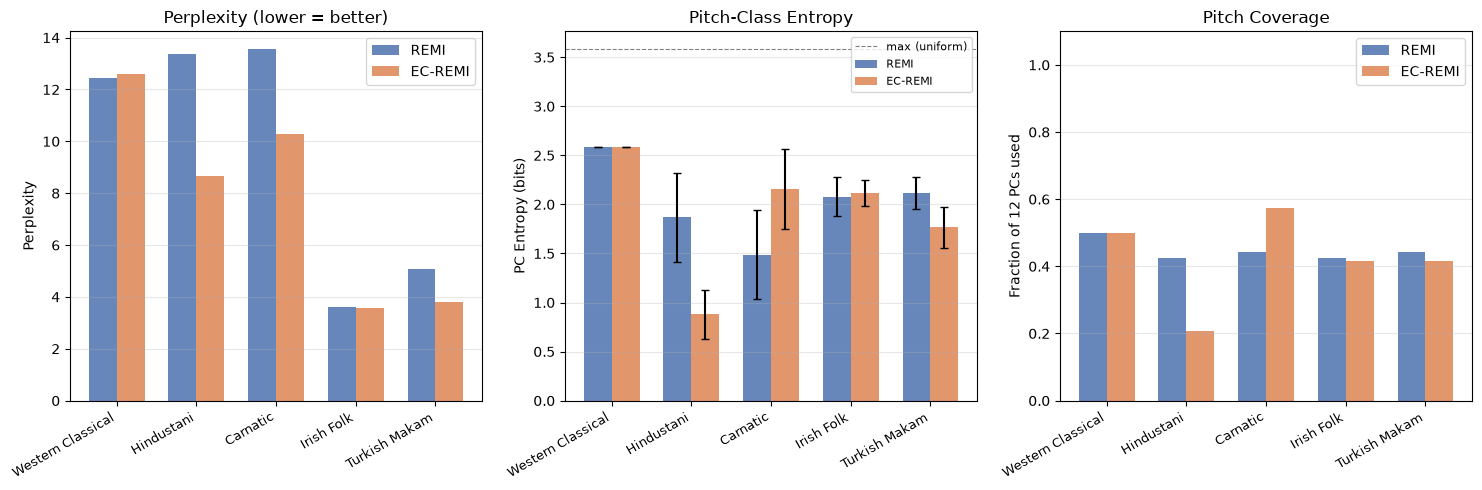

Saved → results/eval_fig1_ppl_entropy_coverage.png


In [12]:
# ── Figure 1: Perplexity + PC Entropy + Pitch Coverage ───────────────────────
TRAD_LABELS = [TRADITION_LABELS[t] for t in TRADITIONS]
x = np.arange(len(TRADITIONS))
w = 0.35
C = {'remi': '#4C72B0', 'ec': '#DD8452'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Perplexity
ax = axes[0]
ax.bar(x - w/2, [df_r.loc[t,  'perplexity'] for t in TRADITIONS], w, label='REMI',    color=C['remi'],  alpha=0.85)
ax.bar(x + w/2, [df_ec.loc[t, 'perplexity'] for t in TRADITIONS], w, label='EC-REMI', color=C['ec'],    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(TRAD_LABELS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Perplexity'); ax.set_title('Perplexity (lower = better)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# PC Entropy
ax = axes[1]
r_ent  = [df_r.loc[t,  'pc_entropy_mean'] for t in TRADITIONS]
ec_ent = [df_ec.loc[t, 'pc_entropy_mean'] for t in TRADITIONS]
r_std  = [df_r.loc[t,  'pc_entropy_std']  for t in TRADITIONS]
ec_std = [df_ec.loc[t, 'pc_entropy_std']  for t in TRADITIONS]
ax.bar(x - w/2, r_ent,  w, yerr=r_std,  label='REMI',    color=C['remi'], alpha=0.85, capsize=3)
ax.bar(x + w/2, ec_ent, w, yerr=ec_std, label='EC-REMI', color=C['ec'],   alpha=0.85, capsize=3)
ax.axhline(3.585, color='grey', linestyle='--', linewidth=0.8, label='max (uniform)')
ax.set_xticks(x); ax.set_xticklabels(TRAD_LABELS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('PC Entropy (bits)'); ax.set_title('Pitch-Class Entropy')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

# Pitch Coverage
ax = axes[2]
ax.bar(x - w/2, [df_r.loc[t,  'pitch_coverage_mean'] for t in TRADITIONS], w, label='REMI',    color=C['remi'], alpha=0.85)
ax.bar(x + w/2, [df_ec.loc[t, 'pitch_coverage_mean'] for t in TRADITIONS], w, label='EC-REMI', color=C['ec'],   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(TRAD_LABELS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Fraction of 12 PCs used'); ax.set_title('Pitch Coverage')
ax.set_ylim(0, 1.1); ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'eval_fig1_ppl_entropy_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/eval_fig1_ppl_entropy_coverage.png')

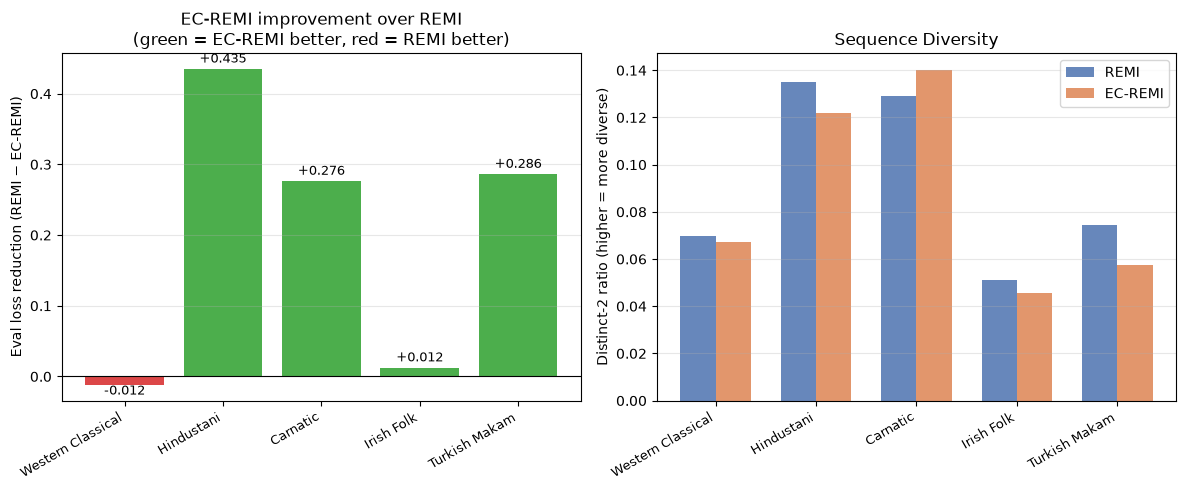

Saved → results/eval_fig2_delta_diversity.png


In [13]:
# ── Figure 2: Eval-loss delta + Distinct-2 diversity ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Eval-loss reduction  (positive = EC-REMI wins)
ax = axes[0]
deltas = [df_r.loc[t, 'eval_loss'] - df_ec.loc[t, 'eval_loss'] for t in TRADITIONS]
bar_c  = ['#2ca02c' if d > 0.005 else ('#d62728' if d < -0.005 else '#999999') for d in deltas]
ax.bar(x, deltas, color=bar_c, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(TRAD_LABELS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Eval loss reduction (REMI − EC-REMI)')
ax.set_title('EC-REMI improvement over REMI\n(green = EC-REMI better, red = REMI better)')
ax.grid(axis='y', alpha=0.3)
for xi, d in zip(x, deltas):
    ax.text(xi, d + (0.005 if d >= 0 else -0.018), f'{d:+.3f}', ha='center', va='bottom', fontsize=9)

# Distinct-2
ax = axes[1]
ax.bar(x - w/2, [df_r.loc[t,  'distinct_2'] for t in TRADITIONS], w, label='REMI',    color=C['remi'], alpha=0.85)
ax.bar(x + w/2, [df_ec.loc[t, 'distinct_2'] for t in TRADITIONS], w, label='EC-REMI', color=C['ec'],   alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(TRAD_LABELS, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Distinct-2 ratio (higher = more diverse)')
ax.set_title('Sequence Diversity')
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS / 'eval_fig2_delta_diversity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/eval_fig2_delta_diversity.png')

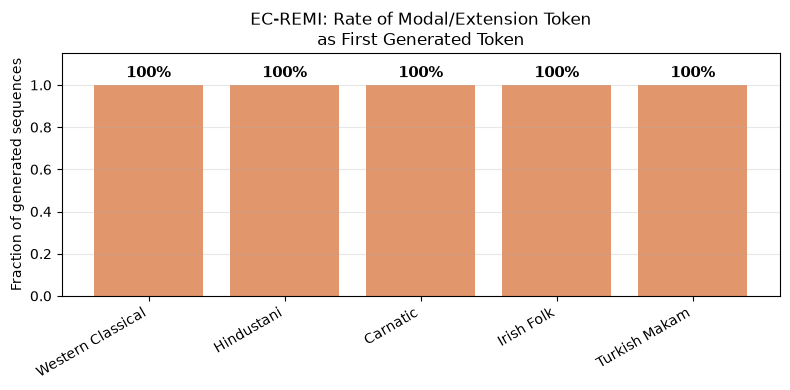

Saved → results/eval_fig3_modal_token_rate.png


In [14]:
# ── Figure 3: EC-REMI modal token rate ───────────────────────────────────────
modal_rates = [df_ec.loc[t, 'modal_token_rate'] for t in TRADITIONS]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(x, modal_rates, color=C['ec'], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(TRAD_LABELS, rotation=30, ha='right')
ax.set_ylabel('Fraction of generated sequences')
ax.set_title('EC-REMI: Rate of Modal/Extension Token\nas First Generated Token')
ax.set_ylim(0, 1.15)
for bar, rate in zip(bars, modal_rates):
    if not np.isnan(rate):
        ax.text(bar.get_x() + bar.get_width()/2, rate + 0.02,
                f'{rate:.0%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'eval_fig3_modal_token_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/eval_fig3_modal_token_rate.png')

In [15]:
# ── Thesis-ready summary table ────────────────────────────────────────────────
print('='*90)
print('TABLE: Step 7 Evaluation Results')
print('='*90)
hdr = (f'{"Tradition":<22}  {"PPL_R":>7} {"PPL_EC":>7}  '
       f'{"Ent_R":>6} {"Ent_EC":>7}  '
       f'{"Cov_R":>6} {"Cov_EC":>7}  '
       f'{"D2_R":>6} {"D2_EC":>6}  {"Δ ppl":>8}')
print(hdr)
print('-' * len(hdr))
for trad in TRADITIONS:
    r  = df_r.loc[trad]
    ec = df_ec.loc[trad]
    dppl = ec['perplexity'] - r['perplexity']
    print(
        f'{TRADITION_LABELS[trad]:<22}  '
        f'{r["perplexity"]:>7.2f} {ec["perplexity"]:>7.2f}  '
        f'{r["pc_entropy_mean"]:>6.3f} {ec["pc_entropy_mean"]:>7.3f}  '
        f'{r["pitch_coverage_mean"]:>6.3f} {ec["pitch_coverage_mean"]:>7.3f}  '
        f'{r["distinct_2"]:>6.3f} {ec["distinct_2"]:>6.3f}  '
        f'{dppl:>+8.3f}'
    )
print('\nColumns: PPL=Perplexity, Ent=PC Entropy (bits), Cov=Pitch Coverage, D2=Distinct-2')
print('R=REMI, EC=EC-REMI. Δ ppl: negative = EC-REMI has lower perplexity (better).')
print()
print('STATISTICAL TEST (Wilcoxon on per-sample PC Entropy):')
print(pd.DataFrame(stat_rows).to_string(index=False))

TABLE: Step 7 Evaluation Results
Tradition                 PPL_R  PPL_EC   Ent_R  Ent_EC   Cov_R  Cov_EC    D2_R  D2_EC     Δ ppl
------------------------------------------------------------------------------------------------
Western Classical         12.45   12.60   2.585   2.585   0.500   0.500   0.070  0.067    +0.148
Hindustani                13.35    8.65   1.868   0.880   0.425   0.208   0.135  0.122    -4.708
Carnatic                  13.56   10.29   1.488   2.153   0.442   0.575   0.129  0.140    -3.272
Irish Folk                 3.60    3.56   2.078   2.116   0.425   0.417   0.051  0.046    -0.043
Turkish Makam              5.07    3.81   2.118   1.766   0.442   0.417   0.075  0.058    -1.260

Columns: PPL=Perplexity, Ent=PC Entropy (bits), Cov=Pitch Coverage, D2=Distinct-2
R=REMI, EC=EC-REMI. Δ ppl: negative = EC-REMI has lower perplexity (better).

STATISTICAL TEST (Wilcoxon on per-sample PC Entropy):
        tradition  remi_pc_entropy  ecremi_pc_entropy  p_value significan